# Previsione Abbandono Universitario
**Hackathon ML** – Obiettivo: massimizzare F1-score Macro

## 1. Preparazione del dataset
Importiamo le librerie necessarie per la creazione del modello.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, ConfusionMatrixDisplay, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42

# StratifiedKFold garantisce che ogni fold abbia la stessa proporzione
# di Dropout/Graduate, fondamentale su dataset sbilanciati
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Librerie caricate correttamente.')

Librerie caricate correttamente.


## 1.2. Esplorazione del Dataset

In [2]:
df_train = pd.read_csv('./CSV/train_dropout.csv')
df_test  = pd.read_csv('./CSV/test_dropout.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test  shape: {df_test.shape}')
df_train.head()

Train shape: (2904, 37)
Test  shape: (726, 36)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,44,1,9003,1,39,150.0,1,19,37,...,0,6,7,6,13.833333,0,13.9,-0.3,0.79,Graduate
1,2,39,1,9991,0,1,135.0,1,34,34,...,0,5,5,0,0.000000,0,7.6,2.6,0.32,Dropout
2,1,1,1,9238,1,1,121.0,1,1,1,...,0,6,7,6,12.142857,0,11.1,0.6,2.02,Graduate
3,1,1,4,9500,1,1,135.0,1,37,37,...,0,8,8,7,13.381429,0,10.8,1.4,1.74,Graduate
4,2,39,1,8014,0,12,110.0,1,34,34,...,2,6,9,6,12.500000,0,7.6,2.6,0.32,Graduate


In [3]:
df_train.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,...,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000
mean,1.185606,18.415289,1.746901,8848.062328,0.888430,4.621212,132.986191,1.755165,20.032369,22.588843,...,0.126033,0.585744,6.288912,7.753099,4.505854,10.014150,0.133264,11.660537,1.227789,0.001009
std,0.613028,17.335091,1.329204,2077.051948,0.314891,10.162905,13.176359,6.206597,15.585075,15.263052,...,0.666059,2.011391,2.252767,3.975813,3.158457,5.499942,0.717246,2.668650,1.380022,2.252360
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.500000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.333333,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,6.000000,9991.000000,1.000000,43.000000,190.000000,105.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2904 entries, 0 to 2903
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  2904 non-null   int64  
 1   Application mode                                2904 non-null   int64  
 2   Application order                               2904 non-null   int64  
 3   Course                                          2904 non-null   int64  
 4   Daytime/evening attendance	                     2904 non-null   int64  
 5   Previous qualification                          2904 non-null   int64  
 6   Previous qualification (grade)                  2904 non-null   float64
 7   Nacionality                                     2904 non-null   int64  
 8   Mother's qualification                          2904 non-null   int64  
 9   Father's qualification                   

In [5]:
# Valori mancanti
valori_null = df_train.isnull().sum()
print('Valori mancanti per colonna:')
print(valori_null[valori_null > 0] if valori_null.any() else 'Nessun valore mancante.')

Valori mancanti per colonna:
Nessun valore mancante.


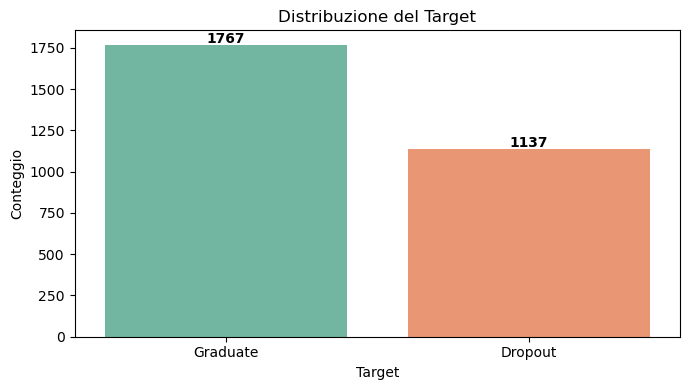

Rapporto Dropout/Graduate: 0.64
⚠️ Dataset sbilanciato → useremo class_weight="balanced" e F1 Macro.


In [6]:
# Analisi del target: verifica sbilanciamento
plt.figure(figsize=(7, 4))
counts = df_train['Target'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='Set2')
plt.title("Distribuzione del Target")
plt.ylabel('Conteggio')
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Rapporto Dropout/Graduate: {counts['Dropout']/counts['Graduate']:.2f}")
print('⚠️ Dataset sbilanciato → useremo class_weight="balanced" e F1 Macro.')

## 2. Feature Engineering
Creiamo nuove variabili partendo dall'intuizione del cliente:
> *"Un ragazzo che passa dal superare 5 esami nel primo semestre a superarne 1 nel secondo è a rischio?"*

In [7]:
def feature_engineering(df):
    df = df.copy()

    # --- HINT DEL CLIENTE: trend negativo degli esami ---
    # Variazione nel numero di esami superati dal 1° al 2° semestre.
    # Un valore negativo indica un peggioramento: segnale di rischio forte.
    df['Esami_Trend'] = (
        df['Curricular units 2nd sem (approved)'] -
        df['Curricular units 1st sem (approved)']
    )

    # --- Tassi di superamento per semestre ---
    df['Pass_Rate_1st'] = np.where(
        df['Curricular units 1st sem (enrolled)'] > 0,
        df['Curricular units 1st sem (approved)'] /
        df['Curricular units 1st sem (enrolled)'], 0)

    df['Pass_Rate_2nd'] = np.where(
        df['Curricular units 2nd sem (enrolled)'] > 0,
        df['Curricular units 2nd sem (approved)'] /
        df['Curricular units 2nd sem (enrolled)'], 0)

    # Trend del tasso di superamento (quanto è migliorato/peggiorato)
    df['Pass_Rate_Trend'] = df['Pass_Rate_2nd'] - df['Pass_Rate_1st']

    # --- Voti medi e trend ---
    df['Grade_Mean']  = (
        df['Curricular units 1st sem (grade)'] +
        df['Curricular units 2nd sem (grade)']) / 2
    df['Grade_Trend'] = (
        df['Curricular units 2nd sem (grade)'] -
        df['Curricular units 1st sem (grade)'])

    # --- Totali complessivi ---
    df['Total_Approved'] = (
        df['Curricular units 1st sem (approved)'] +
        df['Curricular units 2nd sem (approved)'])
    df['Total_Enrolled'] = (
        df['Curricular units 1st sem (enrolled)'] +
        df['Curricular units 2nd sem (enrolled)'])
    df['Overall_Pass_Rate'] = np.where(
        df['Total_Enrolled'] > 0,
        df['Total_Approved'] / df['Total_Enrolled'], 0)

    # --- Flag di rischio accademico ---
    # Studente che NON ha superato nessun esame nel 2° semestre
    df['Zero_2nd_sem']  = (df['Curricular units 2nd sem (approved)'] == 0).astype(int)
    df['Zero_1st_sem']  = (df['Curricular units 1st sem (approved)'] == 0).astype(int)
    df['Both_Zero']     = ((df['Zero_1st_sem'] == 1) & (df['Zero_2nd_sem'] == 1)).astype(int)
    # Calo brusco: almeno 3 esami in meno nel 2° sem rispetto al 1°
    df['Strong_Drop']   = (df['Esami_Trend'] <= -3).astype(int)

    # --- Rischio finanziario ---
    df['Financial_Risk'] = (
        (df['Debtor'] == 1) & (df['Tuition fees up to date'] == 0)
    ).astype(int)

    # --- Interazione: scarso rendimento + problemi economici ---
    df['Academic_x_Financial'] = df['Zero_2nd_sem'] * df['Financial_Risk']

    # --- Qualità media degli esami superati ---
    df['Grade_per_Approved'] = np.where(
        df['Total_Approved'] > 0,
        df['Grade_Mean'] / df['Total_Approved'], 0)

    return df


df_train = feature_engineering(df_train)
df_test  = feature_engineering(df_test)

nuove_feature = [
    'Esami_Trend', 'Pass_Rate_1st', 'Pass_Rate_2nd', 'Pass_Rate_Trend',
    'Grade_Mean', 'Grade_Trend', 'Total_Approved', 'Total_Enrolled',
    'Overall_Pass_Rate', 'Zero_2nd_sem', 'Zero_1st_sem', 'Both_Zero',
    'Strong_Drop', 'Financial_Risk', 'Academic_x_Financial', 'Grade_per_Approved'
]
print(f'Feature aggiunte ({len(nuove_feature)}): {nuove_feature}')

Feature aggiunte (16): ['Esami_Trend', 'Pass_Rate_1st', 'Pass_Rate_2nd', 'Pass_Rate_Trend', 'Grade_Mean', 'Grade_Trend', 'Total_Approved', 'Total_Enrolled', 'Overall_Pass_Rate', 'Zero_2nd_sem', 'Zero_1st_sem', 'Both_Zero', 'Strong_Drop', 'Financial_Risk', 'Academic_x_Financial', 'Grade_per_Approved']


## 3. Preprocessing

In [8]:
# Encoding + splitting X/y
y_full       = df_train['Target'].map({'Graduate': 1, 'Dropout': 0})
X_full       = pd.get_dummies(df_train.drop('Target', axis=1), drop_first=True)
X_test_final = pd.get_dummies(df_test, drop_first=True)

# Allineamento colonne train/test (il test non ha 'Target')
X_full, X_test_final = X_full.align(X_test_final, join='left', axis=1, fill_value=0)

print(f'Feature totali dopo encoding: {X_full.shape[1]}')

# Validation set stratificato (non tocchiamo X_test_final fino alla fine)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

# Scaling (necessario per SVC e LogReg, non cambia RF/XGB ma non fa male)
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_val_sc     = scaler.transform(X_val)
X_full_sc    = scaler.fit_transform(X_full)   # per il training finale
X_test_sc    = scaler.transform(X_test_final)

# Rapporto classi per scale_pos_weight di XGBoost
neg_pos_ratio = float((y_full == 0).sum()) / float((y_full == 1).sum())
print(f'neg/pos ratio: {neg_pos_ratio:.2f}')

Feature totali dopo encoding: 52
neg/pos ratio: 0.64


## 4. Model Selection con RandomizedSearchCV
Definiamo un **dizionario `models`** che associa ogni algoritmo alla propria griglia di iperparametri.
Il loop esegue `RandomizedSearchCV` su ognuno, così troviamo automaticamente il migliore.

In [9]:
# ============================================================
# DIZIONARIO MODELLI + GRIGLIE IPERPARAMETRI
# Ogni entry: 'nome_modello': (istanza_modello, dizionario_parametri)
# ============================================================
models = {

    'DecisionTree': (
        DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        {
            'max_depth':         [3, 5, 8, 12, None],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf':  [1, 2, 5, 10],
            'criterion':         ['gini', 'entropy'],
            'max_features':      ['sqrt', 'log2', None],
        }
    ),

    'RandomForest': (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
        {
            'n_estimators':      [100, 200, 300, 500],
            'max_depth':         [None, 10, 15, 20, 25],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf':  [1, 2, 4],
            'max_features':      ['sqrt', 'log2'],
            'bootstrap':         [True, False],
        }
    ),

    'ExtraTrees': (
        ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
        {
            'n_estimators':      [100, 200, 400],
            'max_depth':         [None, 10, 20],
            'min_samples_split': [2, 5],
            'min_samples_leaf':  [1, 2],
            'max_features':      ['sqrt', 'log2'],
        }
    ),

    'GradientBoosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            'n_estimators':   [100, 200, 300],
            'learning_rate':  [0.01, 0.05, 0.1, 0.2],
            'max_depth':      [3, 4, 5, 6],
            'subsample':      [0.7, 0.8, 1.0],
            'min_samples_split': [2, 5],
            'max_features':   ['sqrt', 'log2'],
        }
    ),

    'XGBoost': (
        XGBClassifier(
            scale_pos_weight=neg_pos_ratio,  # gestisce sbilanciamento
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            'n_estimators':     [200, 300, 500],
            'max_depth':        [3, 4, 5, 6, 7],
            'learning_rate':    [0.01, 0.03, 0.05, 0.1],
            'subsample':        [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'min_child_weight': [1, 3, 5, 7],
            'gamma':            [0, 0.1, 0.2, 0.5],
            'reg_alpha':        [0, 0.1, 0.5, 1.0],
            'reg_lambda':       [1, 1.5, 2, 3],
        }
    ),

    'SVC': (
        SVC(kernel='rbf', class_weight='balanced',
            probability=True, random_state=RANDOM_STATE),
        {
            'C':     [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        }
    ),

    'LogisticRegression': (
        LogisticRegression(
            class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE),
        {
            'C':       [0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver':  ['liblinear', 'saga'],
        }
    ),
}

print(f'Modelli da confrontare: {list(models.keys())}')

Modelli da confrontare: ['DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'XGBoost', 'SVC', 'LogisticRegression']


In [10]:
# ============================================================
# LOOP DI MODEL SELECTION
# Per ogni modello: RandomizedSearchCV con StratifiedKFold
# Metrica di ottimizzazione: f1_macro (penalizza chi ignora Dropout)
# ============================================================

results = {}   # { nome: { 'best_estimator', 'best_score', 'best_params' } }

N_ITER = 20    # numero di combinazioni casuali da provare per modello
               # Aumenta a 30-40 se hai più tempo (migliora il tuning)

print(f'{"Modello":<22} {"F1 Macro CV":>12}  Parametri migliori')
print('=' * 80)

for name, (estimator, param_grid) in models.items():
    search = RandomizedSearchCV(
        estimator      = estimator,
        param_distributions = param_grid,
        n_iter         = N_ITER,
        cv             = CV,          # StratifiedKFold(5)
        scoring        = 'f1_macro',  # metrica dell'hackathon
        n_jobs         = -1,
        random_state   = RANDOM_STATE,
        verbose        = 0,
    )
    search.fit(X_full_sc, y_full)     # usiamo tutto il train per il CV

    results[name] = {
        'best_estimator': search.best_estimator_,
        'best_score':     search.best_score_,
        'best_params':    search.best_params_,
    }

    print(f'{name:<22} {search.best_score_:>12.4f}  {search.best_params_}')

print('=' * 80)

Modello                 F1 Macro CV  Parametri migliori
DecisionTree                 0.8848  {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3, 'criterion': 'gini'}


/usr/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/usr/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used w

RandomForest                 0.9085  {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 25, 'bootstrap': False}
ExtraTrees                   0.9074  {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
GradientBoosting             0.9106  {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.2}
XGBoost                      0.9098  {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}
SVC                          0.9042  {'gamma': 0.001, 'C': 100}
LogisticRegression           0.9033  {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}


In [11]:
# ============================================================
# SELEZIONE AUTOMATICA DEL MODELLO MIGLIORE
# ============================================================

# Riepilogo ordinato per F1 Macro decrescente
summary = pd.DataFrame([
    {'Modello': name, 'F1_Macro_CV': v['best_score']}
    for name, v in results.items()
]).sort_values('F1_Macro_CV', ascending=False).reset_index(drop=True)

print('\n📊 Classifica modelli:')
print(summary.to_string(index=False))

# Il vincitore
best_name  = summary.iloc[0]['Modello']
best_score = summary.iloc[0]['F1_Macro_CV']
best_model = results[best_name]['best_estimator']

print(f'\n✅ Modello scelto: {best_name}  (F1 Macro CV = {best_score:.4f})')
print(f'   Parametri: {results[best_name]["best_params"]}')


📊 Classifica modelli:
           Modello  F1_Macro_CV
  GradientBoosting     0.910644
           XGBoost     0.909801
      RandomForest     0.908478
        ExtraTrees     0.907449
               SVC     0.904205
LogisticRegression     0.903254
      DecisionTree     0.884830

✅ Modello scelto: GradientBoosting  (F1 Macro CV = 0.9106)
   Parametri: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.2}


## 5. Valutazione sul Validation Set

Classification Report (Validation Set):
              precision    recall  f1-score   support

     Dropout       0.92      0.85      0.89       227
    Graduate       0.91      0.95      0.93       354

    accuracy                           0.92       581
   macro avg       0.92      0.90      0.91       581
weighted avg       0.92      0.92      0.92       581

F1 Macro: 0.9101


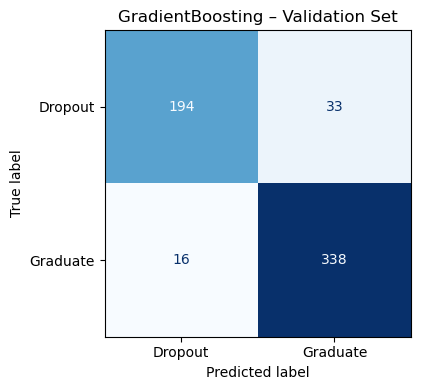

In [12]:
# Allenamento sul training set, valutazione sul val set
best_model.fit(X_train_sc, y_train)
y_pred_val = best_model.predict(X_val_sc)

print('Classification Report (Validation Set):')
print(classification_report(y_val, y_pred_val, target_names=['Dropout', 'Graduate']))
print(f'F1 Macro: {f1_score(y_val, y_pred_val, average="macro"):.4f}')

cm   = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(cm, display_labels=['Dropout', 'Graduate'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{best_name} – Validation Set')
plt.tight_layout()
plt.show()

## 6. Feature Importance (Top 15)

Top 15 feature più importanti:
Curricular units 2nd sem (grade)       0.185194
Pass_Rate_2nd                          0.158565
Overall_Pass_Rate                      0.115580
Curricular units 2nd sem (approved)    0.092228
Pass_Rate_1st                          0.070885
Zero_1st_sem                           0.061099
Tuition fees up to date                0.044692
Total_Approved                         0.037560
Course                                 0.033532
Grade_Mean                             0.022278
Admission grade                        0.012933
Previous qualification (grade)         0.011854
Curricular units 2nd sem (enrolled)    0.011465
Grade_per_Approved                     0.010220
Curricular units 1st sem (grade)       0.009382


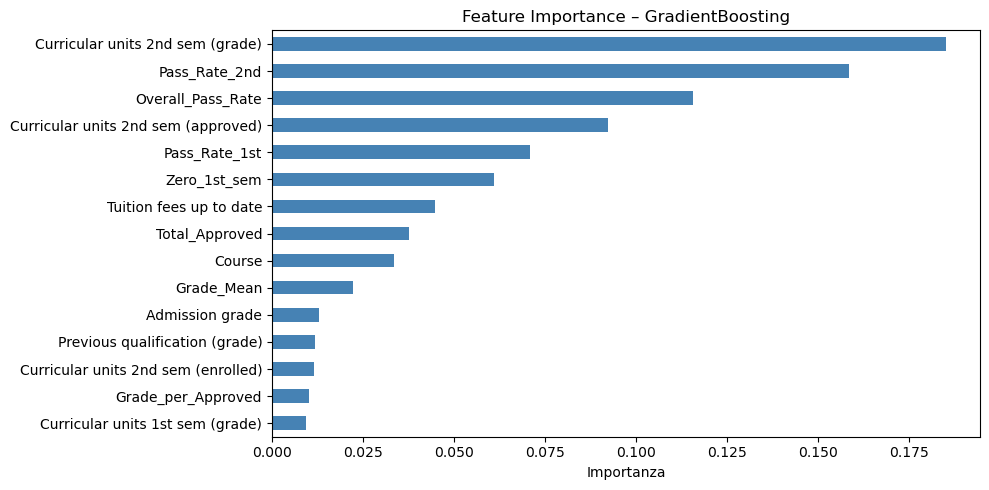

In [13]:
# Funziona per RF, ET, GB, XGBoost, DecisionTree
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_, index=X_full.columns
    ).sort_values(ascending=False)

    print('Top 15 feature più importanti:')
    print(importances.head(15).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    importances.head(15).plot(kind='barh', ax=ax, color='steelblue')
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance – {best_name}')
    ax.set_xlabel('Importanza')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    coef = pd.Series(
        np.abs(best_model.coef_[0]), index=X_full.columns
    ).sort_values(ascending=False)
    print('Top 15 coefficienti (valore assoluto):')
    print(coef.head(15).to_string())
else:
    print(f'Feature importance non disponibile per {best_name}.')

## 7. Predizione Finale e Consegna

In [14]:
# Riaddestriamo il modello su TUTTO il training set (train + val)
# per massimizzare le informazioni disponibili prima della predizione finale
best_model.fit(X_full_sc, y_full)

predizioni_num = best_model.predict(X_test_sc)

# Riconvertiamo da 0/1 a 'Dropout'/'Graduate'
label_map = {1: 'Graduate', 0: 'Dropout'}
predizioni = [label_map[p] for p in predizioni_num]

submission = pd.DataFrame({'Target': predizioni})
submission.to_csv('my_submission.csv', index=False)

print(f'File salvato: my_submission.csv  ({len(submission)} righe)')
print('\nDistribuzione predizioni:')
print(submission['Target'].value_counts())
submission.head()

File salvato: my_submission.csv  (726 righe)

Distribuzione predizioni:
Target
Graduate    475
Dropout     251
Name: count, dtype: int64


,Target
0,Dropout
1,Graduate
2,Graduate
3,Graduate
4,Graduate
